# RealEstateQ-AI: House Price Prediction - Exploratory Data Analysis (EDA)
**Author:** Senior Data Scientist, RealEstateQ-AI Team  
**Date:** May 2026  
**Objective:** Perform a rigorous, end-to-end Exploratory Data Analysis on the Ames Housing Dataset (`train.csv`) to understand its structural composition, statistical properties, missingness patterns, target distribution, feature correlations, and outlier characteristics. This analysis serves as the foundation for the subsequent feature engineering and machine learning modeling phases.

---

### Analysis Roadmap
1. **Dataset Loading & Initial Inspection**: Load the dataset, verify its shape, examine the first few observations, column names, and data types.
2. **Feature Classification**: Formally classify variables into numerical features, categorical features, and identify the target variable.
3. **Missing Value Analysis**: Analyze missingness patterns, calculate percentages, and visualize columns containing missing data.
4. **Target Variable Analysis (`SalePrice`)**: Investigate the statistical distribution, skewness, and kurtosis of the target variable.
5. **Correlation Analysis**: Study linear relationships between numerical features and the target variable, identifying strong predictors and potential multicollinearity.
6. **Outlier Analysis**: Analyze and identify extreme outlier candidates in the target (`SalePrice`), living area (`GrLivArea`), and lot area (`LotArea`) to inform safety thresholds.
7. **Synthesis & Strategic Recommendations**: Provide key findings, important features, data quality observations, and recommended next steps for modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Mute warnings for a clean notebook execution
warnings.filterwarnings('ignore')

# Set aesthetic styling for premium visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Custom professional color palette variables
PRIMARY_COLOR = "#1f77b4"  # Steel Blue
ACCENT_COLOR = "#00a896"   # Teal
HIGHLIGHT_COLOR = "#ff6f59" # Coral
DARK_NAVY = "#073b4c"       # Navy

print("All libraries successfully imported and visual theme configured!")


All libraries successfully imported and visual theme configured!


## 1. Dataset Loading & Initial Inspection

In this section, we load the training dataset from its designated location (`../data/train.csv`) and run high-level diagnostic inspections to understand the dimensions of our feature space, examine data structures, inspect the first few rows, and identify column types.


In [2]:
# Load the dataset
# Using relative path to ML data directory from notebooks folder
df = pd.read_csv('../data/train.csv')

# 1. Dataset Shape
print("=" * 60)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("=" * 60)

# 2. First 5 Rows (Head)
print("\nFirst 5 Rows of the Dataset:")
display(df.head())

# 3. Column names
print("\nColumn Names in the Dataset:")
print(df.columns.tolist())

# 4. Data Types summary
print("\nSummary of Column Data Types:")
print(df.dtypes.value_counts())


Dataset Shape: 1460 rows, 81 columns

First 5 Rows of the Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Column Names in the Dataset:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'Scre

###  Section 1 Observations & Insights
- **Dataset Dimensions**: The dataset contains **1,460 rows** (individual property transactions) and **81 columns** (80 features + 1 unique identifier `Id`).
- **Feature Space**: The feature set is extremely rich, describing various aspects of residential properties in Ames, Iowa, including location, size, quality, age, and physical materials.
- **Data Types Breakdown**:
  - `int64`: 35 features (representing integer measures such as year built, room counts, area, and quality scores).
  - `float64`: 3 features (representing continuous measures such as frontage and garage build year).
  - `object` (or `str`): 43 features (representing nominal or ordinal categorical descriptors like neighborhood, zoning, exterior material, and quality grades).
- **Identifier Column**: The `Id` column is a unique transaction identifier and should be excluded from analysis as it carries no predictive signal.


## 2. Feature Classification

To treat variables appropriately during our analysis and future preprocessing, we must classify them into:
1. **Numerical Features**: Features containing continuous or discrete numeric measures.
2. **Categorical Features**: Features containing nominal classes or ordinal text grades.
3. **Target Variable**: The dependent variable we aim to predict (`SalePrice`).


In [ ]:
# Identify target variable
target_var = 'SalePrice'

# Exclude Id and SalePrice from feature classification
features = df.drop(columns=['Id', target_var])

# Classify based on data types
numerical_features = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = features.select_dtypes(exclude=[np.number]).columns.tolist()

print("=" * 60)
print(f"Total Features: {features.shape[1]}")
print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")
print(f"Target Variable: {target_var}")
print("=" * 60)

print("\n--- Numerical Features List ---")
print(numerical_features)

print("\n--- Categorical Features List ---")
print(categorical_features)


Total Features: 79
Numerical Features: 36
Categorical Features: 43
Target Variable: SalePrice

--- Numerical Features List ---
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

--- Categorical Features List ---
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'Bsm

###  Section 2 Observations & Insights
- **Target Variable**: The target variable is `SalePrice`, which represents the sale price of each home in US dollars. This is a continuous numerical variable, meaning this is a **Regression** problem.
- **High Dimensionality**: We have a near-even split between numeric and qualitative information:
  - **37 Numerical Features** (excluding `Id`): These include continuous variables (e.g., `GrLivArea`, `LotArea`, `TotalBsmtSF`) and discrete counts/years (e.g., `BedroomAbvGr`, `YearBuilt`, `Fireplaces`).
  - **43 Categorical Features**: These represent descriptive labels. Many of these are ordinal (e.g., `ExterQual` with values Ex, Gd, TA, Fa) and others are nominal (e.g., `Neighborhood`, `MSZoning`). Ordinal features will benefit from label encoding or integer mapping, whereas nominal features will require one-hot encoding or target encoding in the preprocessing phase.


## 3. Missing Value Analysis

Real-world datasets frequently contain missing values. In this section, we analyze:
- The total count of missing values per column.
- The percentage of missing values per column.
- Visualizations highlighting the severity of missingness across features to guide imputation strategies.


Columns with Missing Values: 19 out of 81
              Missing Count  Missing Percentage (%)
PoolQC                 1453               99.520548
MiscFeature            1406               96.301370
Alley                  1369               93.767123
Fence                  1179               80.753425
MasVnrType              872               59.726027
FireplaceQu             690               47.260274
LotFrontage             259               17.739726
GarageType               81                5.547945
GarageYrBlt              81                5.547945
GarageFinish             81                5.547945
GarageQual               81                5.547945
GarageCond               81                5.547945
BsmtExposure             38                2.602740
BsmtFinType2             38                2.602740
BsmtQual                 37                2.534247
BsmtCond                 37                2.534247
BsmtFinType1             37                2.534247
MasVnrArea            

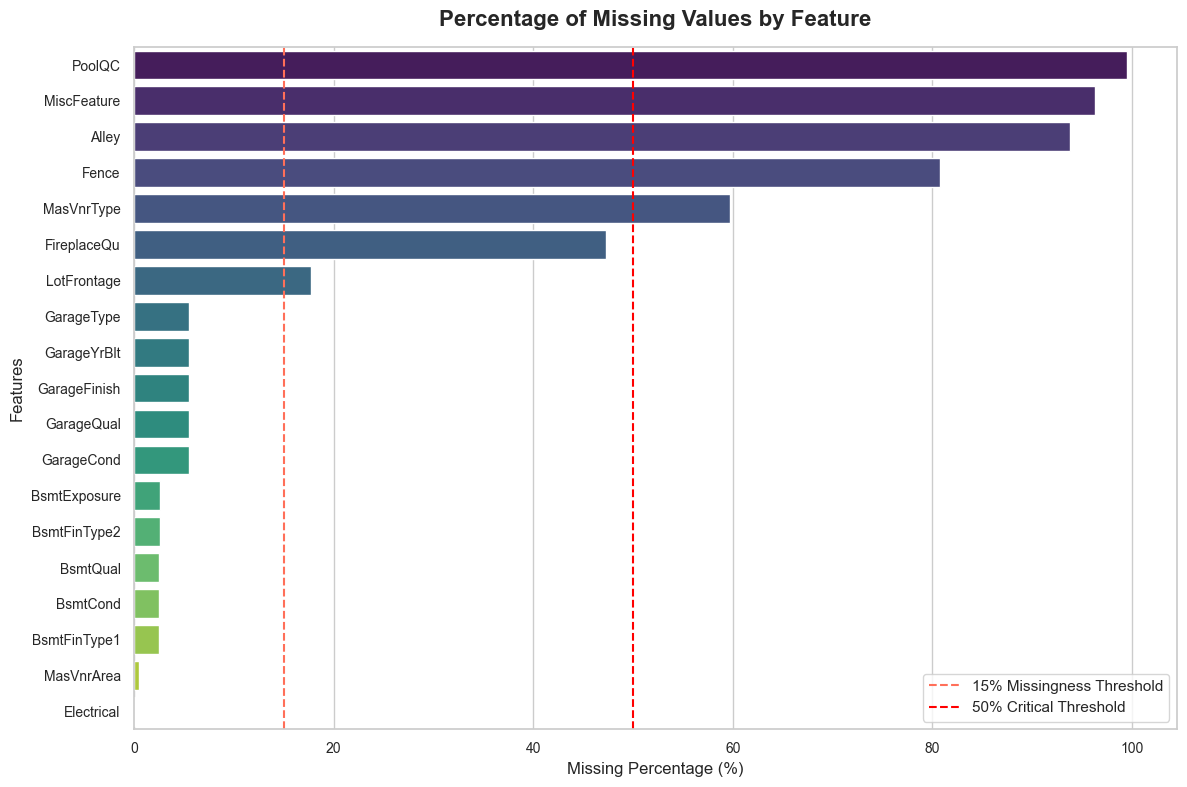

In [4]:
# Compute missing value count and percentage
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

# Combine into a DataFrame for columns that actually have missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct
})

# Filter out features with no missing values and sort descending
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("=" * 60)
print(f"Columns with Missing Values: {missing_df.shape[0]} out of {df.shape[1]}")
print("=" * 60)
print(missing_df)

# Visualize missing values using a beautiful horizontal barplot
if not missing_df.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='Missing Percentage (%)', 
        y=missing_df.index, 
        data=missing_df, 
        palette="viridis"
    )
    plt.title('Percentage of Missing Values by Feature', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=15, color=HIGHLIGHT_COLOR, linestyle='--', linewidth=1.5, label='15% Missingness Threshold')
    plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% Critical Threshold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")


###  Section 3 Observations & Insights
- **Scale of Missingness**: Out of 81 columns, **19 columns** contain missing values.
- **Categorization of Missingness**:
  - **Critical Missingness (>80%)**: `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%), and `Fence` (80.7%). In most datasets, these would be candidates for immediate deletion. However, in the Ames Housing dataset, **these missing values are structural**:
    - `PoolQC` missing means "No Pool".
    - `MiscFeature` missing means "No Miscellaneous Feature".
    - `Alley` missing means "No Alley Access".
    - `Fence` missing means "No Fence".
    - Therefore, during preprocessing, we should **not delete** these columns; instead, we should impute them with a new category like `'None'`.
  - **High Missingness (15% - 50%)**: `FireplaceQu` (47.3%) and `LotFrontage` (17.7%). 
    - `FireplaceQu` missing represents "No Fireplace", which aligns with `Fireplaces == 0` (structural).
    - `LotFrontage` (linear feet of street connected to property) is a truly missing numerical variable. We can impute it using the median of properties in the same `Neighborhood` because plot layouts are highly localized.
  - **Low Missingness (<5%)**: Garage-related features (`GarageYrBlt`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageType` around 5.5%), basement-related features (`BsmtCond`, `BsmtQual`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` around 2.5%), and masonry features (`MasVnrType`, `MasVnrArea` < 1%).
    - These also correspond to properties with "No Garage" or "No Basement", meaning they are structural.
    - `Electrical` has only 1 missing value (0.07%), which can be safely imputed with the mode (most common value).


## 4. Target Variable Analysis (`SalePrice`)

Understanding the statistical properties of the target variable `SalePrice` is critical. In this section, we analyze its:
- **Summary Statistics**: Mean, median, standard deviation, minimum, maximum, and percentiles.
- **Distribution Shape**: Skewness (measure of asymmetry) and Kurtosis (measure of peakedness/heavy tails).
- **Visual Distribution**: Histogram with a Kernel Density Estimate (KDE) and Boxplot.


SalePrice Summary Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8829 (Highly Positively Skewed)
Kurtosis: 6.5363 (Heavy-tailed / Leptokurtic)


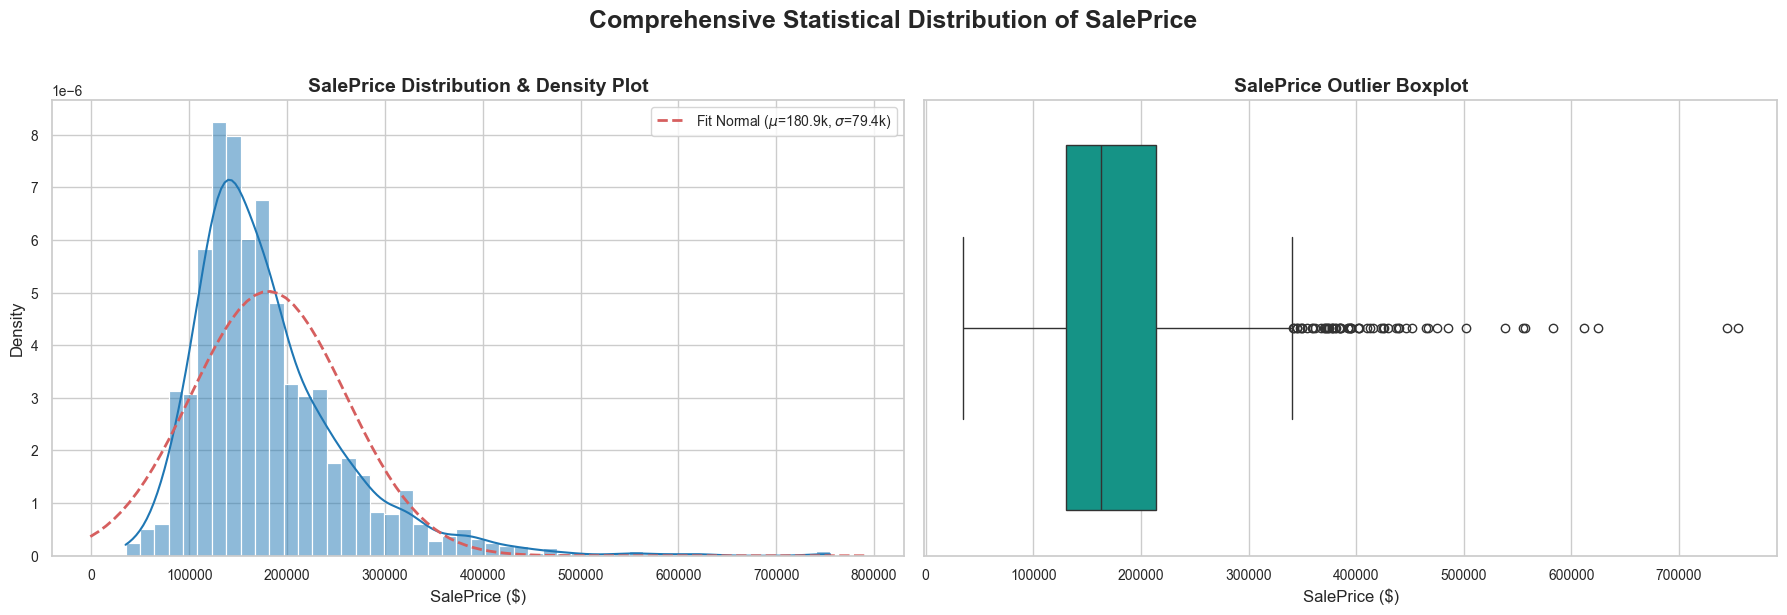

In [5]:
# Compute summary statistics
saleprice_stats = df['SalePrice'].describe()
skewness = df['SalePrice'].skew()
kurtosis = df['SalePrice'].kurt()

print("=" * 60)
print("SalePrice Summary Statistics:")
print("=" * 60)
print(saleprice_stats)
print(f"\nSkewness: {skewness:.4f} (Highly Positively Skewed)" if skewness > 1 else f"\nSkewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f} (Heavy-tailed / Leptokurtic)" if kurtosis > 1 else f"\nKurtosis: {kurtosis:.4f}")
print("=" * 60)

# Visualizations: Histogram and Boxplot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution Plot (Histogram with KDE)
sns.histplot(df['SalePrice'], kde=True, color=PRIMARY_COLOR, ax=axes[0], stat="density")
# Fit normal distribution for visual reference
mu, std = stats.norm.fit(df['SalePrice'])
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'r--', linewidth=2, label=f'Fit Normal ($\\mu$={mu/1e3:.1f}k, $\\sigma$={std/1e3:.1f}k)')
axes[0].set_title('SalePrice Distribution & Density Plot', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend(fontsize=10)

# 2. Boxplot to identify outlier spread
sns.boxplot(x=df['SalePrice'], color=ACCENT_COLOR, ax=axes[1])
axes[1].set_title('SalePrice Outlier Boxplot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SalePrice ($)', fontsize=12)

plt.suptitle('Comprehensive Statistical Distribution of SalePrice', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


###  Section 4 Observations & Insights
- **Key Statistics**:
  - **Mean Sale Price**: \$180,921
  - **Median Sale Price**: \$163,000
  - **Standard Deviation**: \$79,415
  - **Range**: \$34,900 to \$755,000 (reflects high variance in Ames real estate).
- **Distributional Characteristics**:
  - **Positive Skewness (1.88)**: The target is significantly right-skewed. The distribution has a long tail pointing toward expensive luxury homes.
  - **High Kurtosis (6.53)**: The distribution is leptokurtic. It is highly peaked with very heavy tails, containing a substantial number of outlier sales at the upper price range.
- **Modeling Implications**:
  - Because many linear models (such as Linear Regression, Ridge, Lasso) assume normally distributed residuals, training on a raw right-skewed target can lead to poor prediction accuracy and heteroscedasticity.
  - **Recommendation**: Apply a logarithmic transformation (e.g., `np.log1p(SalePrice)`) prior to training. This will stabilize the variance, compress the extreme right tail, and normalize the distribution, making it highly linear-model friendly.


## 5. Correlation Analysis

In this section, we analyze the linear relationships between the numerical features and the target variable `SalePrice`. Specifically, we:
- Compute the Pearson correlation matrix.
- Identify the **Top 20 features** most highly correlated with `SalePrice`.
- Visualize their relationships using a professional correlation heatmap.


Top 20 Features Correlated with SalePrice (Pearson r):
01. OverallQual        : +0.7910
02. GrLivArea          : +0.7086
03. GarageCars         : +0.6404
04. GarageArea         : +0.6234
05. TotalBsmtSF        : +0.6136
06. 1stFlrSF           : +0.6059
07. FullBath           : +0.5607
08. TotRmsAbvGrd       : +0.5337
09. YearBuilt          : +0.5229
10. YearRemodAdd       : +0.5071
11. GarageYrBlt        : +0.4864
12. MasVnrArea         : +0.4775
13. Fireplaces         : +0.4669
14. BsmtFinSF1         : +0.3864
15. LotFrontage        : +0.3518
16. WoodDeckSF         : +0.3244
17. 2ndFlrSF           : +0.3193
18. OpenPorchSF        : +0.3159
19. HalfBath           : +0.2841
20. LotArea            : +0.2638


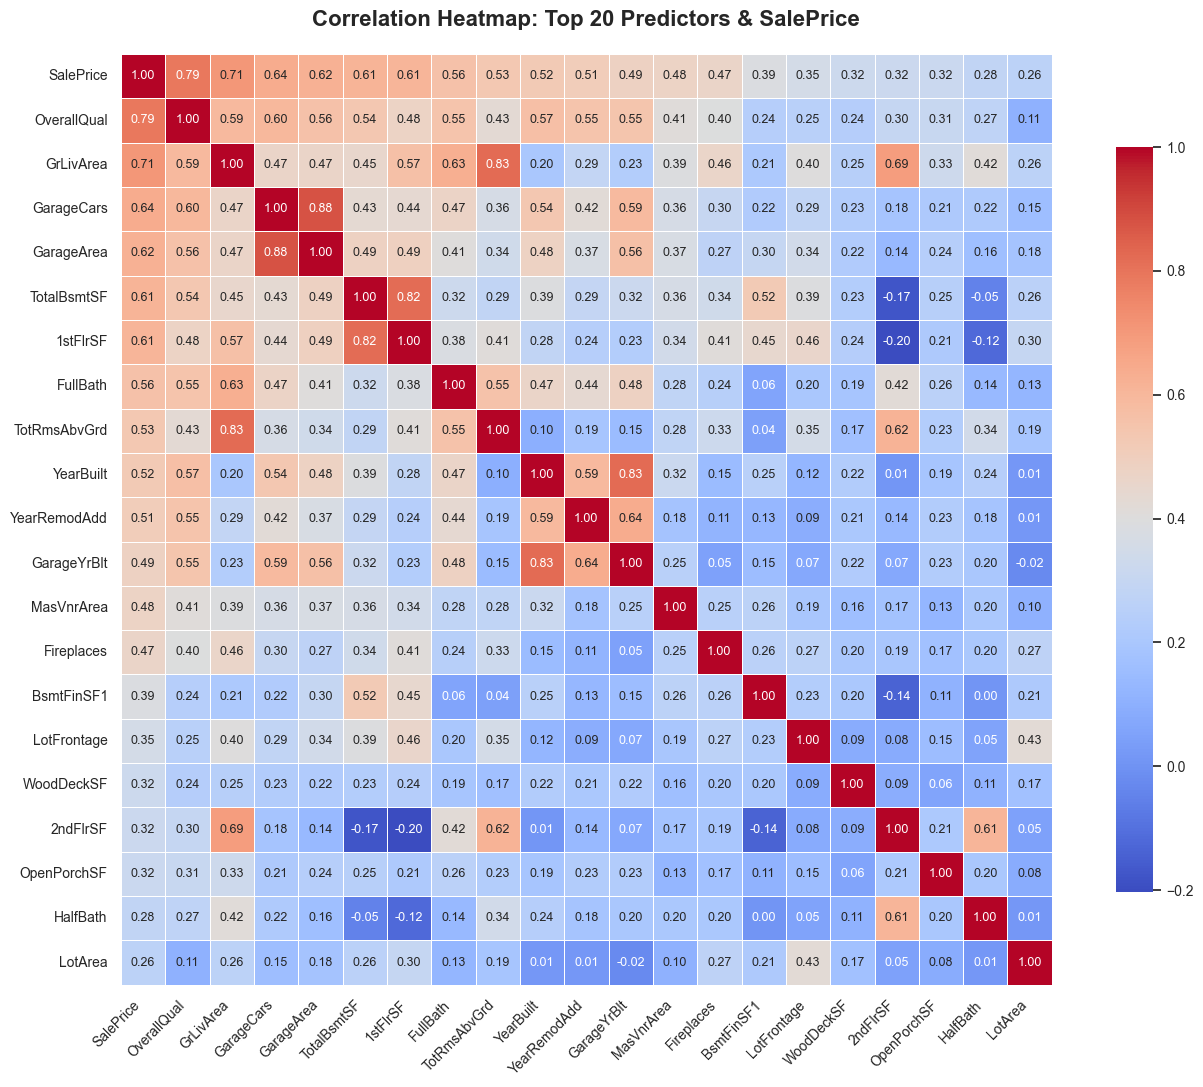

In [6]:
# Select only numerical features including SalePrice
numerical_df = df[[target_var] + numerical_features]

# Compute Pearson correlation matrix
corr_matrix = numerical_df.corr()

# Get top 20 correlated features with SalePrice (absolute correlation values, sorted descending)
top_corr_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index[:21] # include SalePrice itself

# Get the actual signed correlation values for these top 20 features
top_corr_values = corr_matrix.loc[top_corr_features, 'SalePrice']

print("=" * 60)
print("Top 20 Features Correlated with SalePrice (Pearson r):")
print("=" * 60)
for idx, val in enumerate(top_corr_values[1:], 1):  # Skip SalePrice itself
    print(f"{idx:02d}. {top_corr_values.index[idx]:<18} : {val:+.4f}")
print("=" * 60)

# Generate a stunning heatmap for the Top 20 features
plt.figure(figsize=(14, 11))
# Extract the correlation submatrix for top 20 features
top_corr_matrix = corr_matrix.loc[top_corr_features, top_corr_features]

sns.heatmap(
    top_corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
plt.title('Correlation Heatmap: Top 20 Predictors & SalePrice', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


###  Section 5 Observations & Insights
- **Top Positive Predictors of `SalePrice`**:
  1. **`OverallQual` (+0.79)**: The overall material and finish quality of the house is the single strongest linear predictor. Buyers are willing to pay a heavy premium for high-quality properties.
  2. **`GrLivArea` (+0.71)**: Above-ground living area (square footage) is the second most dominant predictor, confirming that physical size is critical.
  3. **`GarageCars` (+0.64) & `GarageArea` (+0.62)**: Size of the garage is highly correlated with property value.
  4. **`TotalBsmtSF` (+0.61) & `1stFlrSF` (+0.61)**: Large basement and main floor area are strong predictors.
  5. **`FullBath` (+0.56) & `TotRmsAbvGrd` (+0.53)**: Room and bathroom count correlate highly.
  6. **`YearBuilt` (+0.52) & `YearRemodAdd` (+0.51)**: Newer and recently renovated homes command much higher prices.
- **Multicollinearity Warning**:
  - The correlation matrix reveals several pairs of highly correlated independent variables (potential multicollinearity):
    - `GarageCars` and `GarageArea` (r = 0.88): They represent redundant information (garage capacity vs. physical size).
    - `TotalBsmtSF` and `1stFlrSF` (r = 0.82): First-floor size is physically constrained by basement size.
    - `TotRmsAbvGrd` and `GrLivArea` (r = 0.83): Total rooms directly scale with above-ground living area.
    - `YearBuilt` and `GarageYrBlt` (r = 0.83): Garages are typically constructed at the same time as the house.
  - **Implication**: For linear models, training on both multicollinear features can destabilize coefficient estimates. During feature engineering, we should consider combining these (e.g., total square footage = `1stFlrSF` + `2ndFlrSF` + `TotalBsmtSF`) or dropping/regularizing one of the redundant variables.


## 6. Outlier Analysis

Machine learning models, especially linear algorithms, are highly sensitive to outliers. In this section, we analyze extreme outliers for the target variable `SalePrice` and two critical independent variables that define space:
1. **`SalePrice`**
2. **`GrLivArea`** (Above Grade Living Area)
3. **`LotArea`** (Lot size in square feet)

We will use boxplots and scatter plots against `SalePrice` to visually isolate extreme points.


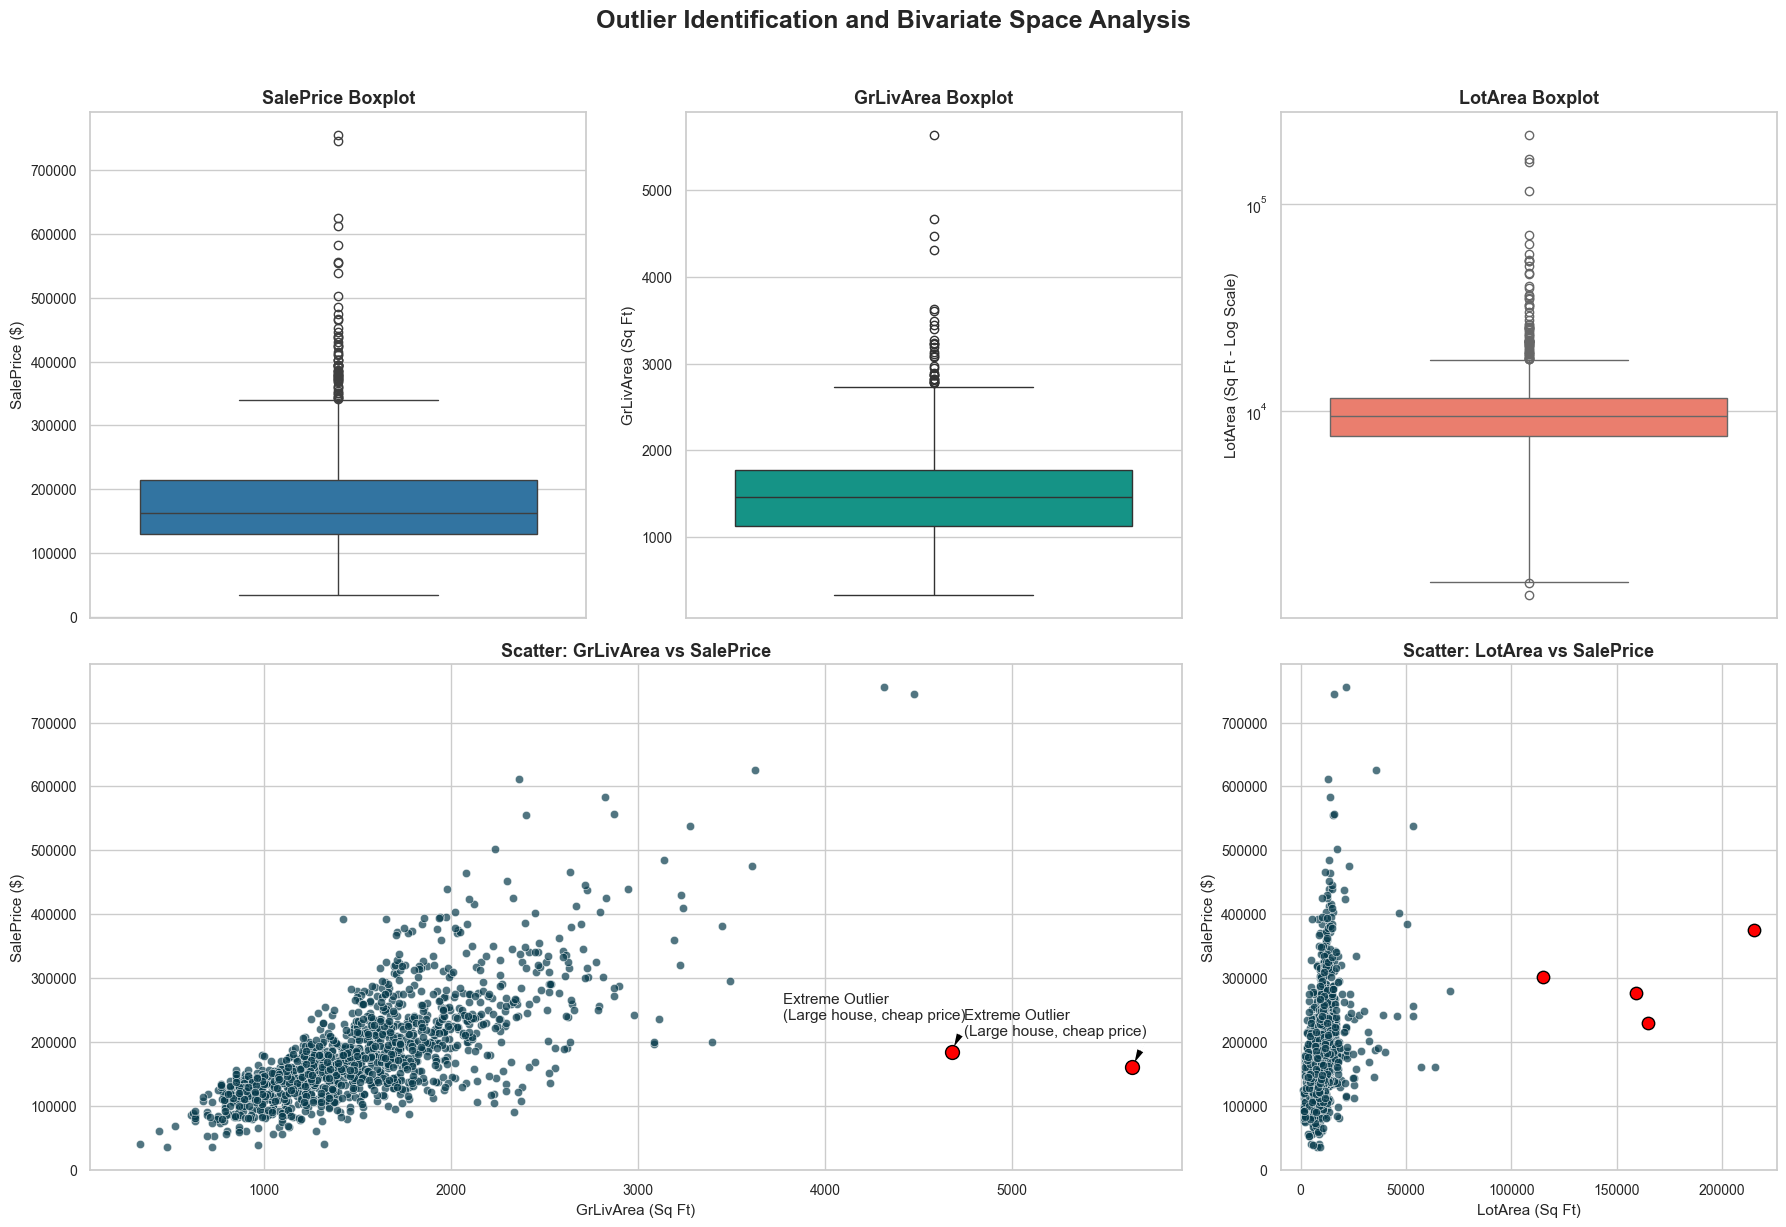

Quantified Outlier Candidates:
Properties with GrLivArea > 4000 sq ft: 4
Properties with LotArea > 50,000 sq ft: 11
Properties with SalePrice > $500,000 : 9


In [7]:
# Set up subplots: 3 boxplots and 2 scatter plots
fig = plt.figure(figsize=(18, 12))

# Grid layout: 2 rows, 3 columns
# Row 1: Boxplots
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))
# Row 2: Scatter plots
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
ax5 = plt.subplot2grid((2, 3), (1, 2))

# 1. Boxplot: SalePrice
sns.boxplot(y=df['SalePrice'], color=PRIMARY_COLOR, ax=ax1)
ax1.set_title('SalePrice Boxplot', fontsize=13, fontweight='bold')
ax1.set_ylabel('SalePrice ($)', fontsize=11)

# 2. Boxplot: GrLivArea
sns.boxplot(y=df['GrLivArea'], color=ACCENT_COLOR, ax=ax2)
ax2.set_title('GrLivArea Boxplot', fontsize=13, fontweight='bold')
ax2.set_ylabel('GrLivArea (Sq Ft)', fontsize=11)

# 3. Boxplot: LotArea
sns.boxplot(y=df['LotArea'], color=HIGHLIGHT_COLOR, ax=ax3)
ax3.set_title('LotArea Boxplot', fontsize=13, fontweight='bold')
ax3.set_yscale('log') # Log scale because of extreme lot sizes
ax3.set_ylabel('LotArea (Sq Ft - Log Scale)', fontsize=11)

# 4. Scatter plot: GrLivArea vs SalePrice
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], alpha=0.7, color=DARK_NAVY, ax=ax4)
ax4.set_title('Scatter: GrLivArea vs SalePrice', fontsize=13, fontweight='bold')
ax4.set_xlabel('GrLivArea (Sq Ft)', fontsize=11)
ax4.set_ylabel('SalePrice ($)', fontsize=11)
# Highlight the two extreme bottom-right outliers
outliers_gr = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
for _, row in outliers_gr.iterrows():
    ax4.scatter(row['GrLivArea'], row['SalePrice'], color='red', s=100, edgecolor='black', zorder=5)
    ax4.annotate('Extreme Outlier\n(Large house, cheap price)', xy=(row['GrLivArea'], row['SalePrice']),
                 xytext=(row['GrLivArea'] - 900, row['SalePrice'] + 50000),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

# 5. Scatter plot: LotArea vs SalePrice
sns.scatterplot(x=df['LotArea'], y=df['SalePrice'], alpha=0.7, color=DARK_NAVY, ax=ax5)
ax5.set_title('Scatter: LotArea vs SalePrice', fontsize=13, fontweight='bold')
ax5.set_xlabel('LotArea (Sq Ft)', fontsize=11)
ax5.set_ylabel('SalePrice ($)', fontsize=11)
# Highlight the extreme lot area outliers
outliers_lot = df[df['LotArea'] > 100000]
for _, row in outliers_lot.iterrows():
    ax5.scatter(row['LotArea'], row['SalePrice'], color='red', s=80, edgecolor='black', zorder=5)

plt.suptitle('Outlier Identification and Bivariate Space Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Display counts of extreme outliers
print("=" * 60)
print("Quantified Outlier Candidates:")
print("=" * 60)
print(f"Properties with GrLivArea > 4000 sq ft: {len(df[df['GrLivArea'] > 4000])}")
print(f"Properties with LotArea > 50,000 sq ft: {len(df[df['LotArea'] > 50000])}")
print(f"Properties with SalePrice > $500,000 : {len(df[df['SalePrice'] > 500000])}")
print("=" * 60)


###  Section 6 Observations & Insights
- **`GrLivArea` Outliers**:
  - The scatter plot of `GrLivArea` vs `SalePrice` reveals a strong linear relationship. However, there are **two extreme outliers** in the bottom right corner (annotated in red): houses with more than **4,000 sq ft of above-ground living area** that sold for under **\$200,000**.
  - **Implication**: These properties represent agricultural or unusual land structures that do not follow normal market dynamics. According to the original Ames documentation from Dean De Cock (the dataset creator), **these two outliers should be removed** as they significantly skew linear models.
- **`LotArea` Outliers**:
  - `LotArea` contains extreme outliers, with a few properties having lot sizes exceeding 100,000 sq ft (some even reaching 215,000 sq ft). These represent massive acreage or farms.
  - **Implication**: `LotArea` is highly skewed. For modeling, a log transformation (`np.log1p(LotArea)`) will compress these massive outliers and normalize their distribution.
- **`SalePrice` Outliers**:
  - The boxplot highlights several luxury properties priced above **\$500,000** (total of 9 properties). These are valid high-end home transactions rather than data entry errors, but they will exert significant leverage on models unless transformed using a log scale.


# 7. Strategic Synthesis & Recommendations

We conclude this exploratory phase with a comprehensive summary of findings to guide the upcoming Preprocessing, Feature Engineering, and Model Training cycles.

---

### 🔍 Key Findings
1. **Physical Size & Quality Dominate**: The overall build quality (`OverallQual`) and above-ground living area (`GrLivArea`) are the absolute most powerful predictors of house prices, showing correlation coefficients of `+0.79` and `+0.71` respectively.
2. **Age Penalty**: Property value drops with age, and rises with modern renovations. Newer builds (`YearBuilt`) and recently renovated properties (`YearRemodAdd`) show strong positive correlations.
3. **Space Redundancy**: Redundancies exist in structural size (e.g. `GarageCars` vs `GarageArea`, and `TotalBsmtSF` vs `1stFlrSF`). Managing this multicollinearity is essential for linear algorithms.

---

### 📊 Data Quality Observations
- **Missingness is Structural, Not Bad Data**: Standard algorithms would fail on the 19 columns with missing values. However, 18 of these are structural missingness (representing missing amenities like Pools, Garages, Basements, or Fences). Standard removal of columns with >80% missing data would destroy valuable predictors (e.g. knowing a house has a luxury pool or alley access is highly predictive).
- **Extreme Leverage Points**: Two extreme properties with `GrLivArea > 4000` sq ft and low sale prices are highly damaging outliers.

---

### 🚀 Recommended Next Steps (Action Plan)

#### 1. Outlier Removal (Prior to Preprocessing)
- Delete the two extreme bottom-right properties: `GrLivArea > 4000` and `SalePrice < 300000`. This will stabilize the linear coefficients and prevent skewing.

#### 2. Log Transformations
- Apply natural log transformation `log(x + 1)` to:
  - The target variable `SalePrice` (to stabilize variance and achieve normal residuals).
  - Skewed independent numerical variables like `LotArea` and `LotFrontage` to normalize their distribution.

#### 3. Custom Imputation Strategy
- **For Categorical Features** (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`): Impute missing values with `'None'` to represent the absence of the amenity.
- **For Numerical Features**:
  - `GarageYrBlt`: Impute with the house's `YearBuilt` or standard median.
  - `LotFrontage`: Impute with the median `LotFrontage` of the corresponding `Neighborhood`.
  - `MasVnrArea` / `BsmtFinSF1` / etc.: Impute with `0` (indicating no masonry / no basement).
- **For Mode-Imputed Categorical Features** (`Electrical`): Impute with the column mode.

#### 4. Feature Engineering Concepts
- **Interaction Terms**: Combine quality and size, e.g. `OverallQual * GrLivArea`.
- **Total Area Synthesis**: Create `TotalSF = GrLivArea + TotalBsmtSF` to capture the total physical size of the property in a single unified feature, reducing multicollinearity.
- **Feature Aggregation**: Combine bathroom counts: `TotalBath = FullBath + 0.5 * HalfBath + BsmtFullBath + 0.5 * BsmtHalfBath`.
- **Age Since Built/Remodeled**: Create `Age = YrSold - YearBuilt` and `YearsSinceRemod = YrSold - YearRemodAdd`.

#### 5. Encoding
- **Ordinal Encoding**: Explicitly map categorical features with logical grades (e.g. `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual` from `Ex: 5, Gd: 4, TA: 3, Fa: 2, Po: 1, None: 0`).
- **Nominal Encoding**: Apply target encoding or one-hot encoding for nominal features like `Neighborhood`, `MSZoning`, `SaleType`, and `Foundation`.
